## Simulation of hits from windows chosen by probability

In [2]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import uniform
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import pyvista as pv
from scipy.stats import norm
import scipy.stats as stats 
import math

from helpers import geometry, rwbeams, sampler, rwhist, collision, coord

# Geometry

In [3]:
BEAM_RADIUS = 0.14 #meters
TARGET_RADIUS = 0.001 #meters 
CHAMBER_RADIUS = 1.65 #meters 
WINDOW_SIZE = 0.30 #meters

### Import of the excel data frame

In [4]:
# =====================================================
# Chargement de la configuration Master
# =====================================================

# On utilise le module beams pour lire et VALIDER le fichier excel
# que tu as créé dans ton notebook "parameters"
df_omega = rwbeams.read_beams("omega60_master_config.xlsx")


df_omega.head()

,id,LAT_rad,LONG_rad,energy,wavelength,l1,l2,xc,yc,zc,...,t1x,t1y,t1z,t2x,t2y,t2z,R,fx,fy,fz
0,OMEGA_J01,0.203169,1.570796,500,3.510000e-07,0.28,0.28,2.038592e-17,0.332927,1.616063,...,-1.000000,6.123234e-17,0,-5.997292e-17,-0.979432,0.201774,0.14,-6.818032e-20,-0.001113,-0.005405
1,OMEGA_J02,0.203169,4.712389,500,3.510000e-07,0.28,0.28,-6.115775e-17,-0.332927,1.616063,...,1.000000,-1.836970e-16,0,1.799188e-16,0.979432,0.201774,0.14,2.045410e-19,0.001113,-0.005405
2,OMEGA_J03,0.545768,0.890581,500,3.510000e-07,0.28,0.28,5.386876e-01,0.665855,1.410303,...,-0.777438,6.289602e-01,0,-5.375904e-01,-0.664498,0.519075,0.14,-1.801631e-03,-0.002227,-0.004717
3,OMEGA_J04,0.545768,2.251011,500,3.510000e-07,0.28,0.28,-5.386876e-01,0.665855,1.410303,...,-0.777438,-6.289602e-01,0,5.375904e-01,-0.664498,0.519075,0.14,1.801631e-03,-0.002227,-0.004717
4,OMEGA_J05,0.545768,4.032174,500,3.510000e-07,0.28,0.28,-5.386876e-01,-0.665855,1.410303,...,0.777438,-6.289602e-01,0,5.375904e-01,0.664498,0.519075,0.14,1.801631e-03,0.002227,-0.004717


## INPUT

In [5]:
# --- Execution ---

N_total=60000 #Number of impact (rays) that you want to simulate


total_impact = collision.impact_simulated(N_total, TARGET_RADIUS, np.array([0.0, 0.0, 0.0]), df_omega)

print(f"Simulation Monte-Carlo complétée.")
print(f"Total de rayons lancés : {N_total}")
print(f"Total d'impacts enregistrés sur la cible : {len(total_impact)}")

total_impact.head()

Simulation terminée : 60000 impacts valides enregistrés.
Simulation Monte-Carlo complétée.
Total de rayons lancés : 60000
Total d'impacts enregistrés sur la cible : 60000


,id,cs,l,xx,xy,xz,ux,uy,uz,xsphx,xsphy,xsphz,nx,ny,nz,r,long_rad,lat_rad,R,energy_weight
0,OMEGA_J01,-0.9916,1.6495,0.0382,0.3269,1.6173,-0.0231,-0.1981,-0.9799,0.0002,0.0002,0.001,0.1503,0.1756,0.9729,0.001,0.8629,0.2332,0.14,0.4836
1,OMEGA_J01,-0.9996,1.6490,-0.0069,0.3279,1.6171,0.0042,-0.1988,-0.9800,-0.0000,0.0002,0.001,-0.0273,0.1820,0.9829,0.001,1.7199,0.1851,0.14,0.4836
2,OMEGA_J01,-0.9997,1.6490,0.0068,0.3301,1.6167,-0.0041,-0.2000,-0.9798,0.0000,0.0002,0.001,0.0268,0.1904,0.9813,0.001,1.4310,0.1934,0.14,0.4836
3,OMEGA_J01,-0.9974,1.6491,0.0137,0.3168,1.6194,-0.0083,-0.1920,-0.9814,0.0001,0.0001,0.001,0.0539,0.1374,0.9890,0.001,1.1971,0.1481,0.14,0.4836
4,OMEGA_J01,-0.9879,1.6497,-0.0012,0.2874,1.6254,0.0007,-0.1742,-0.9847,-0.0000,0.0000,0.001,-0.0047,0.0198,0.9998,0.001,1.8032,0.0203,0.14,0.4836


## Histogram of impacts in a 1m radius sphere

Creation of mesh on a sphere 

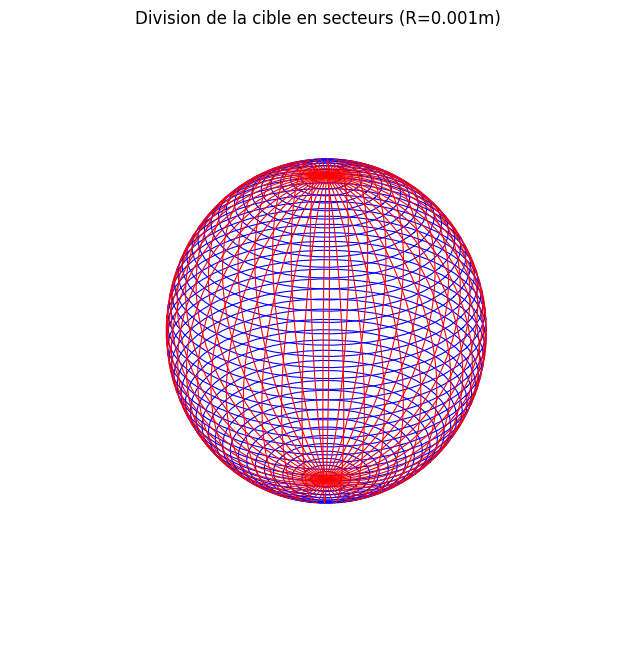

In [6]:
# 1. Création des secteurs (La grille est créée pour r=1 par défaut)
num_theta = 50
num_phi = 50
# On ne met PAS de radius ici, d'où l'erreur
sectors = rwhist.SphereSectors.factory(num_theta, num_phi) 

# 2. Affichage de la grille sur ta cible (Le radius se met ICI)
# La méthode plot_mesh remplace toutes tes boucles 'for' manuelles
fig, ax = sectors.plot_mesh(radius=TARGET_RADIUS)

# 3. Optionnel : On peut aussi afficher les centres des secteurs
# fig, ax = sectors.plot_centers(radius=TARGET_RADIUS, kwargs={'color': 'red', 's': 5})

ax.set_title(f"Division de la cible en secteurs (R={TARGET_RADIUS}m)")
plt.show()

Plot the center of each sectors on the mesh

Somme des aires calculées : 12.56637 (Attendu: 12.56637)


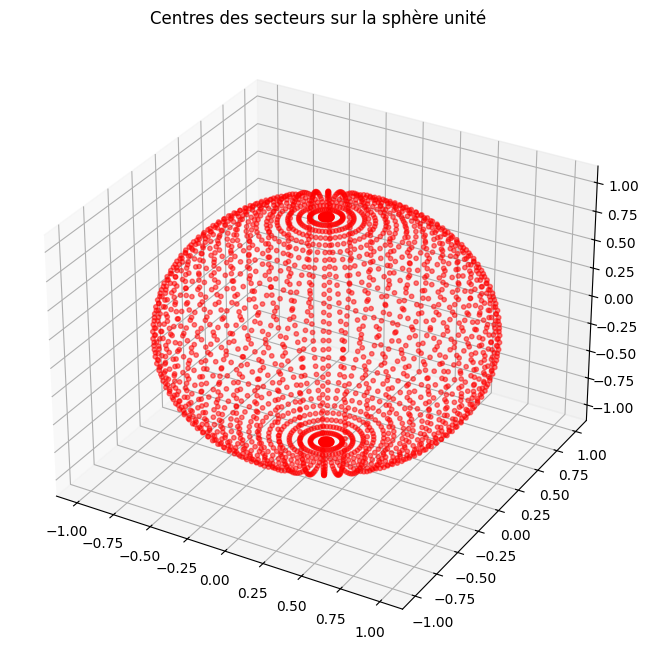

In [7]:
# 1. Calcul des aires et Vérification
# C'EST DÉJÀ FAIT ! factory() a déjà calculé 'sectors.areas' et vérifié la somme.
# Tu peux simplement vérifier la valeur si tu veux :
print(f"Somme des aires calculées : {np.sum(sectors.areas):.5f} (Attendu: {4*np.pi:.5f})")

# 2. Remplacement du scatter plot manuel
# La méthode plot_centers() fait déjà le 'coord.sph_to_cart' en interne.
# Tu peux passer tes paramètres graphiques (alpha, s, color) dans le dictionnaire 'kwargs'.
fig, ax = sectors.plot_centers(radius=1.0, kwargs={'alpha': 0.5, 's': 10, 'color': 'red'})

ax.set_title("Centres des secteurs sur la sphère unité")
plt.show()

## Histogram

In [8]:
hits = total_impact[total_impact['cs'] < 0]

df_hist = rwhist.compute_histogram(hits, sectors)

Import the 2D histogram into a csv file

In [9]:
from helpers import rwhist

# On reprend la colonne 'intensity' et on lui redonne sa forme 50x50
# .values transforme en NumPy, .reshape redonne la forme de la grille
histogram_numpy = df_hist['intensity'].values.reshape(sectors.mtheta.shape)


# 'hs_density' est la matrice 2D (50x50) calculée dans compute_histogram
# 'sectors' contient les bords (edges) de ta grille
rwhist.write_histogram(
    sectors.theta_edges, 
    sectors.phi_edges, 
    histogram_numpy, 
    "omega60_illumination_map.csv"
)

print("Fichier exporté pour le calcul des harmoniques sphériques.")

Fichier exporté pour le calcul des harmoniques sphériques.


## Showing 3D histogram

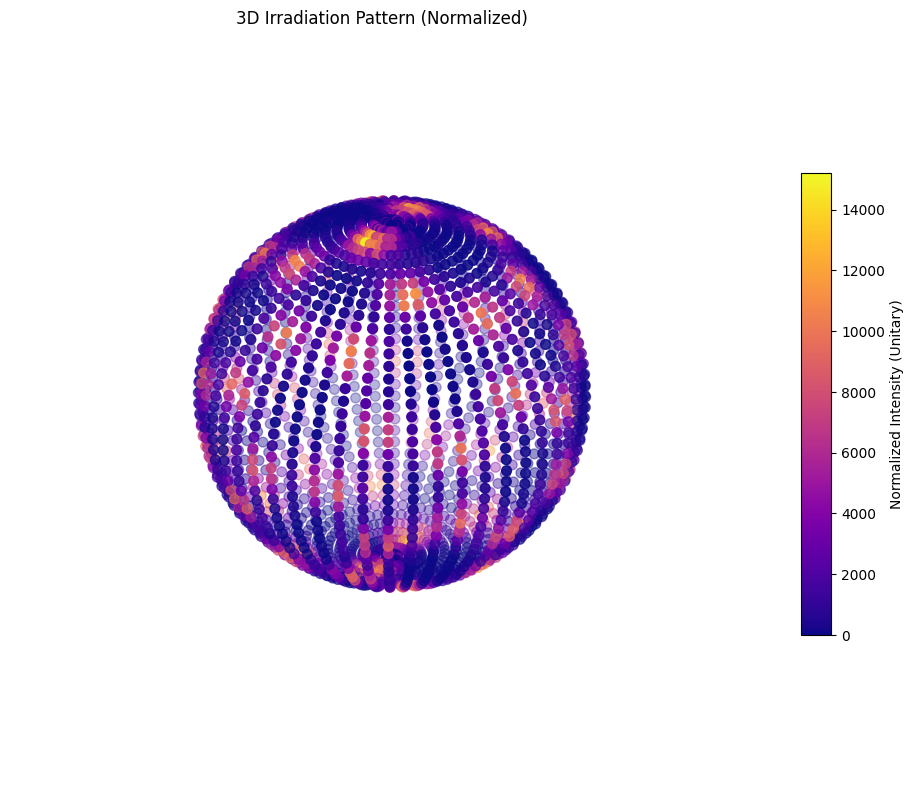

In [10]:
fig = plt.figure(figsize=(12, 12)) # Un peu plus petit pour que ce soit plus fluide
ax = fig.add_subplot(111, projection='3d')

# On récupère les valeurs (hs_unit est la normalisation physique que ton maître veut)
hs = df_hist['intensity'].values

# Conversion en coordonnées Cartésiennes
xs, ys, zs = coord.sph_to_cart(1.0, sectors.mtheta, sectors.mphi)

X, Y, Z = xs.ravel(), ys.ravel(), zs.ravel()
C = hs.ravel() 

# --- LA CORRECTION EST ICI ---
# On force l'échelle de couleurs à coller au minimum et au maximum de tes données
# C'est ce qui transforme le "tout bleu" en "taches colorées"
p = ax.scatter(X, Y, Z, c=C, cmap='plasma', s=50, vmin=C.min(), vmax=C.max())

# Colorbar (on l'affine un peu)
cb = fig.colorbar(p, ax=ax, shrink=0.5, aspect=15)
cb.set_label("Normalized Intensity (Unitary)")

ax.set_box_aspect([1, 1, 1])
ax.set_title("3D Irradiation Pattern (Normalized)")
ax.set_axis_off()

plt.show()

## Integrated intensity

In [11]:
def compute_theta_distribution(df_final_map):
    """
    Intègre I(theta, phi) sur phi pour obtenir le profil moyen I(theta).
    Calcule également l'erreur relative globale du tir.
    """
    # 1. On regroupe par theta et on calcule la moyenne de l'intensité
    theta_profile = df_final_map.groupby('theta')['intensity'].mean().reset_index()
    
    # 2. Renommer pour la clarté
    theta_profile.columns = ['theta_rad', 'intensity_avg']
    
    # 3. Conversion en degrés pour le graphique
    theta_profile['theta_deg'] = np.degrees(theta_profile['theta_rad'])
    
    # 4. Normalisation du profil
    avg_total = theta_profile['intensity_avg'].mean()
    theta_profile['variation_pct'] = (theta_profile['intensity_avg'] / avg_total - 1) * 100
    
    # --- LIGNE AJOUTÉE ---
    # Calcul de l'erreur relative globale (e = std/mean) selon le schéma
    relative_error = df_final_map['intensity'].std() / df_final_map['intensity'].mean()
    
    return theta_profile, relative_error

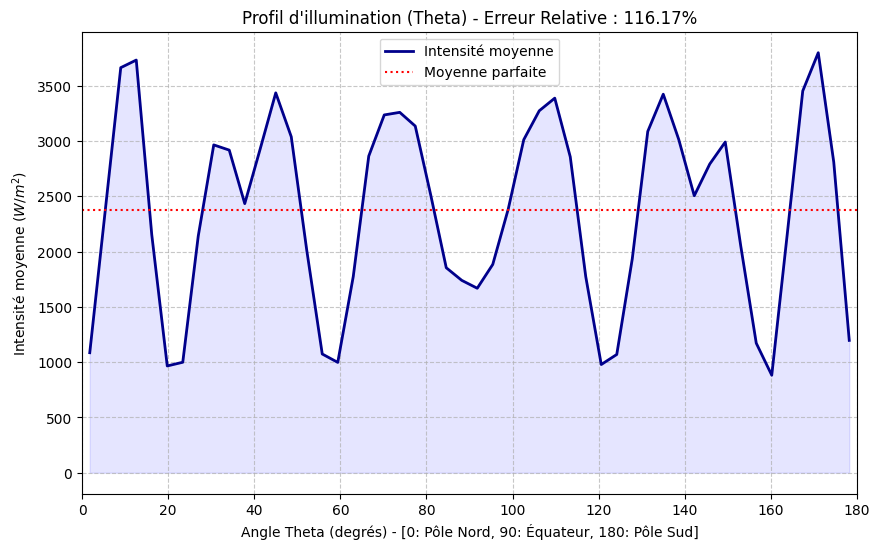

L'erreur relative globale (std/mean) est de : 116.1651 %


In [12]:
# --- EXÉCUTION ---
# IMPORTANT : On récupère maintenant DEUX variables
df_theta, rel_err = compute_theta_distribution(df_hist)

# --- VISUALISATION ---
plt.figure(figsize=(10, 6))

# Tracé de la courbe
plt.plot(df_theta['theta_deg'], df_theta['intensity_avg'], color='darkblue', lw=2, label='Intensité moyenne')
plt.fill_between(df_theta['theta_deg'], df_theta['intensity_avg'], color='blue', alpha=0.1)

# --- CHANGEMENT ICI : Affichage de l'erreur relative sur le graphique ---
# On affiche la valeur 'rel_err' (multipliée par 100 pour l'avoir en %)
plt.title(f"Profil d'illumination (Theta) - Erreur Relative : {rel_err*100:.2f}%")

# Esthétique
plt.xlabel("Angle Theta (degrés) - [0: Pôle Nord, 90: Équateur, 180: Pôle Sud]")
plt.ylabel("Intensité moyenne ($W/m^2$)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 180)

# Ajout d'une ligne horizontale pour l'intensité moyenne parfaite
plt.axhline(df_theta['intensity_avg'].mean(), color='red', linestyle=':', label='Moyenne parfaite')

plt.legend()
plt.show()

# Affichage dans le terminal pour ton suivi
print(f"L'erreur relative globale (std/mean) est de : {rel_err*100:.4f} %")

Test cosign

In [13]:
def test_lambert_law_consistency(num_rays=1000000):
    # A. On récupère les paramètres d'un faisceau de test
    df_beam = rwbeams.params_testing_lambert() 
    
    # B. On génère les rayons parallèles (on force la direction)
    direction = np.array([-1, 0, 0]) # nx du faisceau de test
    t1 = np.array([0, 1, 0])
    t2 = np.array([0, 0, -1])
    
    origins = sampler.sample_window(t1, t2, l1=0.003, l2=0.003, center=[1.65, 0, 0], num_points=num_rays)
    
    # C. Simulation des impacts
    hits_list = []
    for x0 in origins:
        res = sampler.ray_hit(x0, direction, radius=0.001, center=[0,0,0])
        if res[2] > 0:
            hits_list.append({
                'lat_rad': res[5][1], 
                'long_rad': res[5][2],
                'energy_weight': 1.0, # Énergie uniforme
                'cs': res[4]          # LE COSINUS D'INCIDENCE
            })
    
    df_hits = pd.DataFrame(hits_list)
    
    # D. Passage dans ta fonction rwhist.compute_histogram
    sectors = rwhist.SphereSectors.factory(num_theta=60, num_phi=120)
    df_res = rwhist.compute_histogram(df_hits, sectors)
    
    return df_res


2D intensity

In [14]:
# A. On calcule l'histogramme 2D (la grille sur la sphère)
# df_hits contient : lat_rad, long_rad, energy_weight, cs
sectors = rwhist.SphereSectors.factory(num_theta=60, num_phi=120)
df_res = test_lambert_law_consistency() #

# B. On utilise TA fonction pour obtenir le profil 1D (Moyenne sur phi)
# df_res possède les colonnes 'theta' et 'intensity' dont ta fonction a besoin
theta_profile, error_globale = compute_theta_distribution(df_res) 

# C. On prépare la normalisation pour le graphique
max_val = theta_profile['intensity_avg'].max() 

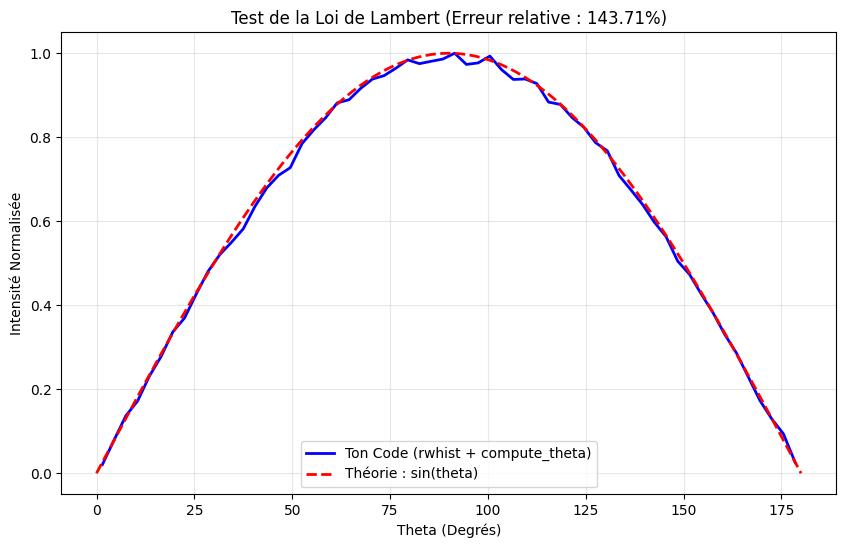

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 1. Ta simulation (utilisant tes fonctions)
# On trace l'intensité moyenne normalisée en fonction des degrés
plt.plot(theta_profile['theta_deg'], 
         theta_profile['intensity_avg'] / max_val, 
         label='Ton Code (rwhist + compute_theta)', color='blue', lw=2)

# 2. La théorie de ton maître de stage (sin theta)
theta_theory = np.linspace(0, np.pi, 100)
plt.plot(np.degrees(theta_theory), np.sin(theta_theory), 
         'r--', label='Théorie : sin(theta)', lw=2)

# Configuration de l'affichage
plt.title(f"Test de la Loi de Lambert (Erreur relative : {error_globale:.2%})")
plt.xlabel("Theta (Degrés)")
plt.ylabel("Intensité Normalisée")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Optimisation with sigma/mu

### 

## Pyvista representation 

In [16]:
import nest_asyncio

# On applique le patch une seule fois au début
nest_asyncio.apply()

def plot_omega_histogram_pyvista(sectors, hs, target_radius=0.001, cmap='plasma', filename="simulation_omega60.html"):
    """
    Affiche l'histogramme sphérique d'énergie sur la cible et exporte en HTML.
    """
    # 1. Conversion des coordonnées
    display_radius = target_radius * 1.05 
    xs, ys, zs = coord.sph_to_cart(display_radius, sectors.mtheta, sectors.mphi)

    # 2. Préparation des données
    points = np.column_stack([xs.ravel(), ys.ravel(), zs.ravel()])
    densities = hs.ravel()

    # 3. Création des objets PyVista
    point_cloud = pv.PolyData(points)
    point_cloud["Irradiance"] = densities
    target_sphere = pv.Sphere(radius=target_radius, center=(0, 0, 0), theta_resolution=100, phi_resolution=100)

    # 4. Configuration du Plotter
    pv.set_jupyter_backend('trame')
    plotter = pv.Plotter(window_size=[800, 600])
    plotter.background_color = "white"

    # Ajout des éléments à la scène
    plotter.add_mesh(target_sphere, color="lightgrey", opacity=0.3, label="Cible")
    plotter.add_mesh(
        point_cloud,
        scalars="Irradiance",
        cmap=cmap,
        render_points_as_spheres=True,
        point_size=10, 
        show_scalar_bar=True,
        scalar_bar_args={"title": "Energie normalisée (J/mm2)"}
    )

    plotter.add_title("Distribution Sphérique de l'Energie - OMEGA-60")
    plotter.add_legend()
    plotter.view_isometric()

    # --- ÉTAPE CRUCIALE : EXPORT AVANT LE SHOW ---
    # On utilise l'argument 'filename' passé à la fonction
    plotter.export_html(filename) 
    print(f"Fichier interactif sauvegardé : {filename}")

    # Affichage dans le Notebook
    plotter.show()

# --- UTILISATION ---
plot_omega_histogram_pyvista(sectors, hs, target_radius=TARGET_RADIUS, cmap='plasma', filename="simulation_omega60.html")

ValueError: Number of scalars (2500) must match either the number of points (7200) or the number of cells (7200).